# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [48]:
!pip install google-play-scraper
import pandas as pd
import time

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [49]:
# Scrapping Dataset
from google_play_scraper import reviews, Sort

scrapreview = []
token = None

while len(scrapreview) < 4000:
    data, token = reviews(
        'id.co.linebank',
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=200,
        continuation_token=token
    )

    scrapreview.extend(data)

    if not token:
        break

    time.sleep(0.5)

app_reviews_df = pd.DataFrame(scrapreview[:4000])

print(
    "Total sampel data ulasan Line Bank yang didapat:",
    app_reviews_df.shape[0]
)

Total sampel data ulasan Line Bank yang didapat: 4000


In [50]:
# Menyimpan seluruh hasil scraping ke CSV
app_reviews_df.to_csv(
    'linebank_reviews_raw.csv',
    index=False
)

print(
    "Dataset berhasil disimpan:",
    app_reviews_df.shape
)

Dataset berhasil disimpan: (4000, 11)


In [51]:
app_reviews_df = pd.DataFrame(scrapreview[:4000])

app_reviews_df.to_csv(
    'linebank_reviews_raw.csv',
    index=False
)

print(app_reviews_df.columns)

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')


In [52]:
# Menampilkan lima baris pertama
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6435f401-e35e-472e-bbf1-fcf859f34801,Rans,https://play-lh.googleusercontent.com/a/ACg8oc...,Program dan internalnya lebih memadai di pakai...,5,3,2.4.10,2026-06-22 13:44:49,None,NaT,2.4.10
1,0974fc7f-f2b2-4091-b328-ca98633123d8,Aditya Wicaksono,https://play-lh.googleusercontent.com/a/ACg8oc...,"Untuk versi yang sekarang bagus UI-nya, tetap ...",5,18,2.4.5,2026-04-15 00:38:26,None,NaT,2.4.5
2,2c82aa49-43f5-4b12-86c3-7778a6ad6287,R G,https://play-lh.googleusercontent.com/a-/ALV-U...,"aduuuh gmn dong, udah buka rekening, dah pakai...",1,4,2.4.10,2026-06-11 10:15:56,Hi Sobat LINE Bank! Mohon maaf atas ketidaknya...,2026-06-11 10:03:09,2.4.10
3,369d6e86-3b63-4e04-986c-6d13f592c6e5,rayhan azzikri,https://play-lh.googleusercontent.com/a-/ALV-U...,"Saya kesulitan login hingga Beberapa kali, cha...",2,3,2.4.9,2026-06-04 14:26:29,Hi Sobat LINE Bank! Mohon maaf atas ketidaknya...,2026-06-05 07:35:21,2.4.9
4,6b691b81-780a-4512-bc68-71aaceead2a7,Afifah Firdayansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,Perbaikin dong applikasinya lemot bgttt bahkan...,2,4,2.4.10,2026-06-13 07:07:58,Hi Sobat LINE Bank! Mohon maaf atas ketidaknya...,2026-06-15 10:47:46,2.4.10


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [53]:
# Informasi Dataset
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              4000 non-null   object        
 1   userName              4000 non-null   object        
 2   userImage             4000 non-null   object        
 3   content               4000 non-null   object        
 4   score                 4000 non-null   int64         
 5   thumbsUpCount         4000 non-null   int64         
 6   reviewCreatedVersion  3046 non-null   object        
 7   at                    4000 non-null   datetime64[ns]
 8   replyContent          2231 non-null   object        
 9   repliedAt             2231 non-null   datetime64[ns]
 10  appVersion            3046 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 343.9+ KB


In [54]:
# Statistik Deskriptif
app_reviews_df.describe()

,score,thumbsUpCount,at,repliedAt
count,4000.00000,4000.000000,4000,2231
mean,2.52725,8.664500,2023-02-12 01:32:12.494000128,2023-04-19 13:12:05.495741952
min,1.00000,0.000000,2021-06-10 02:07:51,2021-06-10 04:51:37
25%,1.00000,0.000000,2021-12-22 23:58:30,2021-12-09 15:46:03.500000
50%,2.00000,1.000000,2022-09-25 19:11:44.500000,2023-06-13 12:02:31
75%,5.00000,4.000000,2023-12-19 06:03:04.750000128,2024-06-10 10:07:23.500000
max,5.00000,1113.000000,2026-07-01 03:09:38,2026-07-01 04:45:45
std,1.69867,37.463486,NaN,NaN


In [55]:
# Missing Value
app_reviews_df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,954
at,0
replyContent,1769
repliedAt,1769


In [56]:
# Duplicate
app_reviews_df.duplicated().sum()

np.int64(0)

In [57]:
# Distribusi Rating
app_reviews_df['score'].value_counts()

,count
score,
1,1913
5,1026
2,397
3,384
4,280


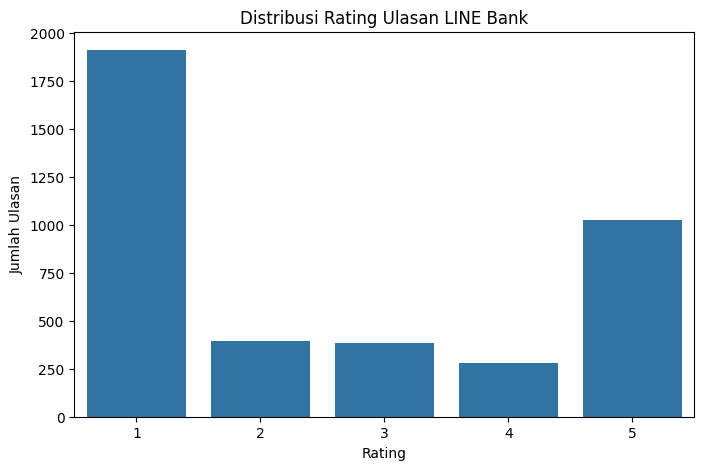

In [58]:
# Visualisasi Distribusi Rating
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='score',
    data=app_reviews_df
)

plt.title('Distribusi Rating Ulasan LINE Bank')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [59]:
# Memilih kolom yang digunakan
df = app_reviews_df[['content', 'score']]

# Mengecek missing value kembali
df.isnull().sum()

,0
content,0
score,0


In [60]:
# Menghapus data duplikat
df = df.drop_duplicates()

print(
    "Jumlah data setelah menghapus duplikat:",
    df.shape[0]
)

Jumlah data setelah menghapus duplikat: 4000


In [61]:
# Mengubah nama kolom
df.columns = [
    'review',
    'rating'
]

df.head()

,review,rating
0,Program dan internalnya lebih memadai di pakai...,5
1,"Untuk versi yang sekarang bagus UI-nya, tetap ...",5
2,"aduuuh gmn dong, udah buka rekening, dah pakai...",1
3,"Saya kesulitan login hingga Beberapa kali, cha...",2
4,Perbaikin dong applikasinya lemot bgttt bahkan...,2


In [62]:
def sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['rating'].apply(sentiment)

In [63]:
# Distribusi sentimen
df['sentiment'].value_counts()

,count
sentiment,
negative,2310
positive,1306
neutral,384


In [64]:
# Melihat hasil labeling
df.head()

,review,rating,sentiment
0,Program dan internalnya lebih memadai di pakai...,5,positive
1,"Untuk versi yang sekarang bagus UI-nya, tetap ...",5,positive
2,"aduuuh gmn dong, udah buka rekening, dah pakai...",1,negative
3,"Saya kesulitan login hingga Beberapa kali, cha...",2,negative
4,Perbaikin dong applikasinya lemot bgttt bahkan...,2,negative


In [65]:
# Mengubah teks menjadi huruf kecil (Case folding)
df['review'] = df['review'].astype(str).str.lower()

In [66]:
# Remove Mention
df['review'] = df['review'].apply(
    lambda x: re.sub(r'@[A-Za-z0-9_]+', '', x)
)

# Remove Hashtag
df['review'] = df['review'].apply(
    lambda x: re.sub(r'#[A-Za-z0-9_]+', '', x)
)

# Remove RT
df['review'] = df['review'].apply(
    lambda x: re.sub(r'RT[\s]+', '', x)
)

# Remove URL
import re

df['review'] = df['review'].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)

#Remove Number
df['review'] = df['review'].str.replace(
    r'\d+',
    '',
    regex=True
)

# Remove Punctuation
import string

df['review'] = df['review'].apply(
    lambda x: x.translate(
        str.maketrans('', '', string.punctuation)
    )
)

# Remove Extra Spaces
df['review'] = df['review'].apply(
    lambda x: ' '.join(x.split())
)

df.head()

,review,rating,sentiment
0,program dan internalnya lebih memadai di pakai...,5,positive
1,untuk versi yang sekarang bagus uinya tetap si...,5,positive
2,aduuuh gmn dong udah buka rekening dah pakai d...,1,negative
3,saya kesulitan login hingga beberapa kali chat...,2,negative
4,perbaikin dong applikasinya lemot bgttt bahkan...,2,negative


In [67]:
# Hasil
df[['review', 'sentiment']].head()

,review,sentiment
0,program dan internalnya lebih memadai di pakai...,positive
1,untuk versi yang sekarang bagus uinya tetap si...,positive
2,aduuuh gmn dong udah buka rekening dah pakai d...,negative
3,saya kesulitan login hingga beberapa kali chat...,negative
4,perbaikin dong applikasinya lemot bgttt bahkan...,negative


In [68]:
# Simpan Dataset
df.to_csv(
    'linebank_reviews_preprocessed.csv',
    index=False
)

print(
    "Dataset preprocessing berhasil disimpan"
)

Dataset preprocessing berhasil disimpan
